# Sleep Study Dataset Analysis

My goal for this analysis was to understand human sleep behaviour using the "sleepstudy.csv" dataset. The dataset has information about the sleep duration, efficieny, REM, deep, and light sleep percentages of the participants. As well as some lifestyle factors like caffeine and alcohol consumption, exercise frequency, and smoking status. Using this data, we have the goal to understand how demographic facotrs and habits in the daily life influence sleep quality and duration. 

This analysis will include statistics, visualizations, and correlations to provide insights into which factors are most strongly associated with better or worse sleep. Understanding the patterns in the dataset can help with knowing healthier habits for sleep and overall lifestyle.

In [1]:
#Load Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load csv file and check if it loaded correctly
df = pd.read_csv("../data/sleepstudy.csv")
#df.head()

In [3]:
#Summary Statistics
df.describe(include = "all")

,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
count,1000.000000,1000.000000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,744.000000,1000.000000,1000,1000.000000
unique,NaN,NaN,2,1000,990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,Male,2025-09-30 7:32,42:25.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,NaN,513,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,513,NaN
mean,500.500000,50.125000,NaN,NaN,NaN,7.027443,0.720150,22.460000,47.357000,30.183000,2.539000,25.168011,2.560000,NaN,2.565000
std,288.819436,18.076397,NaN,NaN,NaN,1.135365,0.128139,4.589059,13.097293,13.788968,1.726691,20.446036,1.746267,NaN,1.712515
min,1.000000,18.000000,NaN,NaN,NaN,5.002335,0.500000,15.000000,25.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,250.750000,34.000000,NaN,NaN,NaN,6.076980,0.610000,18.000000,36.000000,18.000000,1.000000,0.000000,1.000000,NaN,1.000000
50%,500.500000,51.000000,NaN,NaN,NaN,6.981505,0.720000,22.000000,47.000000,30.000000,3.000000,25.000000,3.000000,NaN,3.000000
75%,750.250000,65.000000,NaN,NaN,NaN,8.039587,0.830000,27.000000,59.000000,42.000000,4.000000,50.000000,4.000000,NaN,4.000000


In [4]:
#Count missing values in each column
df.isnull().sum()

ID                        0
Age                       0
Gender                    0
Bedtime                   0
WakeupTime                0
SleepDuration             0
SleepEfficiency           0
REMSleepPercentage        0
DeepSleepPercentage       0
LightSleepPercentage      0
Awakenings                0
CaffeineConsumption     256
AlcoholConsumption        0
SmokingStatus             0
ExerciseFrequency         0
dtype: int64

In [5]:
#Shape of dataset to help with Basic Summary section
df.shape

(1000, 15)

In [6]:
#Figuring out the percentage of smokers for descriptive insights

smoker_percentage = (df['SmokingStatus'] == 'Yes').mean() * 100
print(round(smoker_percentage, 2))


51.3


## Basic Summary

This dataset has info on participants sleep paterns and lifestyle habits. Columns include SleepDuration, SleepEfficiency, REMSleepPercentage, DeepSleepPercentage, LightSleepPercentage, lifestyle habits like CaffeineConsumption, AlcoholConsumption, SmokingStatus, and ExerciseFrequency, along with Age and Gender. There are 1000 columns and 15 rows with 256 entries in "CaffeineConsumption" being blank.

## Descriptive Statistics

### Age

Participants range from 18-80 years old, with a median age of 51. The interquartile range (34–65) indicates that the middle 50% of participants fall within this age range.

### Sleep Duration

On average participants sleep about 7 hours per night (mean = 7.027 hours), with a range of 5 to 9 hours across the whole dataset. Most of the dataset falls between the 6-8 hour range (the IQR).

### Sleep Efficiency

Average sleep efficency is around 72% with most participants between 61% and 83% (the 25th and 75th percentile respect). Some participants however, have very low sleep efficency (50%), while some reach a very high efficiency (95%).

### Sleep Stages

REM Sleep (~22% of total sleep):

In this dataset, participants spend an average of approximately 22% of their total sleep time in REM sleep. The interquartile range shows that most fall between roughly 18% and 27%, indicated moderate variation across individuals.

This suggests that REM sleep makes up about one-fifth of total sleep for most participants in this sample



Deep Sleep (~47% of total sleep):

Deep sleep accounts for an average of approximately 47% of total sleep in this dataset. The middle 50% of participants fall between roughly 36% and 59%, indicating that deep sleep represents the largest proportion of total sleep for most individuals in this sample.

There is noticeable variability in deep sleep percentages across participants, but it consistently represents a substantial portion of overall sleep time in this dataset.

Light Sleep (~30% of total sleep):

In this dataset, light sleep accounts for an average of approximtely 30% of total sleep time. The interquartile range indicates that most participants fall between rougly 18% and 42%, showing modertate variability across individuals.

Compared to REM and deep sleep percentages int his dataset, light sleep represents a substantial but not dominant portion of total sleep time for most participants.

### Awakenings

In this dataset, participants report between 0 and 5 awakenings per night, with a median of 3 awakenings. The median of 3 suggests that half of participants experience three or fewer awakenings per night, and half experience three or more.

### Lifestyle Factors

Exercise Frequency: Most participants exercise 0-5 days per week (median 3). More frequent exercise is generally linked to better sleep quality

Caffeine Consumption: Caffeine intake varies widely (0-50 mg/day). Higher caffeince use may reduce sleep duration or efficiency

Alcohol Consumption: Alcohol consumption ranges 0-5 ounces per day. Higher alcohol can interrupt sleep cycles and ruin sleep quality

Smoking Status: About half of the participants being smokers. Nicotine can negatively effect sleep duration and efficiency

## Visual Analysis

### Distribution of Sleep Duration

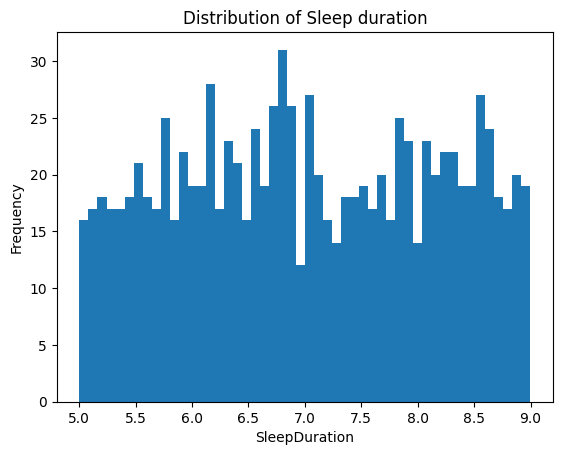

In [7]:
plt.hist(df["SleepDuration"], bins=50)

plt.xlabel("SleepDuration")
plt.ylabel("Frequency")
plt.title("Distribution of Sleep duration")

plt.show()

Sleep duration in this dataset ranges from approximately 5 to 9 hours, with most values clustered between 6 and 8 hours.

### Average Sleep Duration by Gender

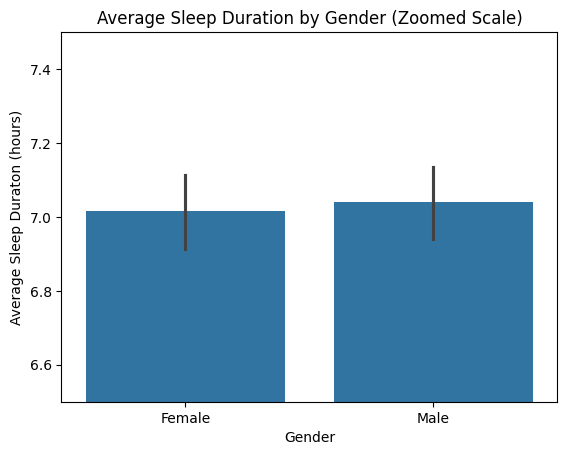

In [8]:
sns.barplot(
    data=df,
    x="Gender",
    y="SleepDuration"
)

plt.ylim(6.5,7.5) #this changes the rnage of the y axis, allowing for a more zoomed visual

plt.title("Average Sleep Duration by Gender (Zoomed Scale)")
plt.ylabel("Average Sleep Duraton (hours)")

plt.show()

The graph shows that males and females have very similar average sleep durations, with males only being slightly more. The lack of difference between these two demographics suggests that there may be other factors that contribute to higher quality sleep and duration.

### Caffeine Consumption vs Sleep Duration

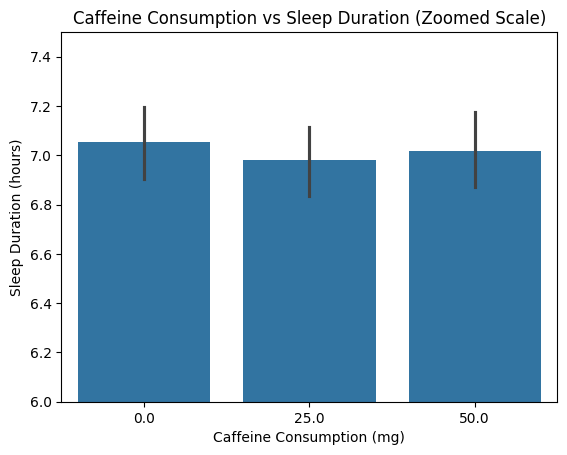

In [9]:
sns.barplot(
    data=df,
    x="CaffeineConsumption",
    y="SleepDuration"
)
plt.ylim(6,7.5) #same zoomed scale code

plt.title("Caffeine Consumption vs Sleep Duration (Zoomed Scale)")
plt.ylabel("Sleep Duration (hours)")
plt.xlabel("Caffeine Consumption (mg)")

plt.show()

In this dataset, average sleep duration varies slightly across caffein consumption categories. Sleep duraton appears somewhat lower at the 25mg level compared to 0mg and 50mg, though the differences are small and the error bars overlap, indicating variability within groups.

The pattern is not strictly increasing or decreasing across caffeine levels, suggesting that the relationship between caffeine consumption and sleep duration is not consistent in this dataset.

It is also important to note that the CaffeineConsumption column contains 256 missing values, which may influence the reliability of comparisons across categories.

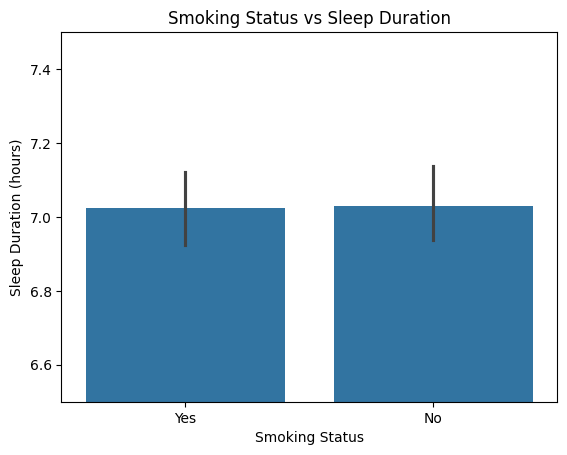

In [10]:
sns.barplot(
    data=df,
    x="SmokingStatus",
    y="SleepDuration"
)
plt.ylim(6.5,7.5)

plt.title("Smoking Status vs Sleep Duration")
plt.ylabel("Sleep Duration (hours)")
plt.xlabel("Smoking Status")

plt.show()

In this dataset, average sleep duration is very similar between smokers and non-smokers. Smokers sleep only slightly fewer hours on average, and the difference between groups is small with overlapping variability.

These results indicate minimal separation in average sleep duration between smoking categories within this dataset.

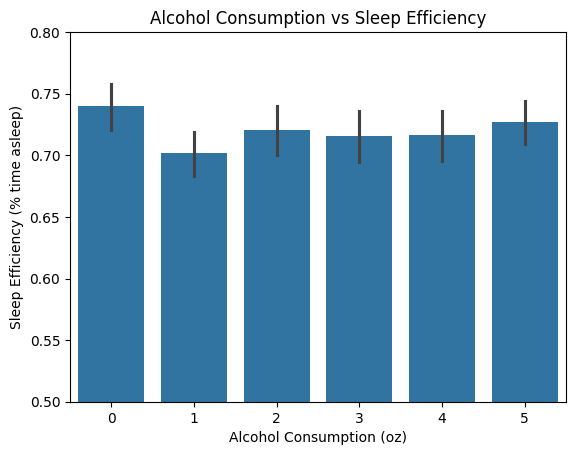

In [11]:
sns.barplot(
    data=df,
    x="AlcoholConsumption",
    y="SleepEfficiency"
)
plt.ylim(0.5,0.8)

plt.title("Alcohol Consumption vs Sleep Efficiency")
plt.ylabel("Sleep Efficiency (% time asleep)")
plt.xlabel("Alcohol Consumption (oz)")

plt.show()

In this dataset, higher alcohol consumption categories are associated with lower average sleep efficiency. The downward pattern across categories suggests a negative relationship between alcohol consumption and sleep efficiency within this sample.

However, because this dataset is observational, these findings describe associations rather than causal effects.

### Exercise Frequency vs Sleep Duration

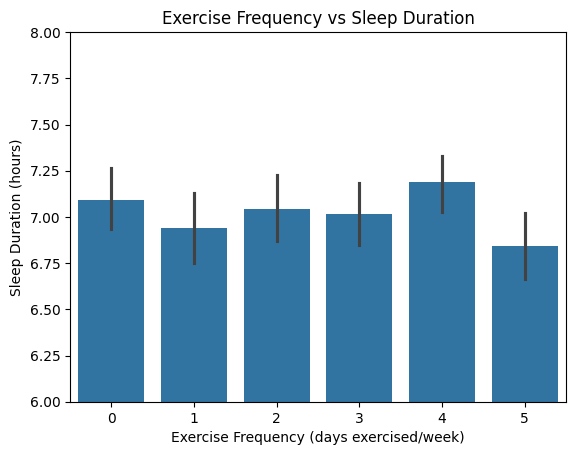

In [12]:
sns.barplot(
    data=df,
    x="ExerciseFrequency",
    y="SleepDuration"
)
plt.ylim(6, 8) 

plt.title("Exercise Frequency vs Sleep Duration")
plt.ylabel("Sleep Duration (hours)")
plt.xlabel("Exercise Frequency (days exercised/week)")

plt.show()

In this dataset, participants who exercise around 4 days per week show the highest average sleep duraton. Sleep duration appears slightly lower at 5 days per week, though differences across categories are modest and variability within groups is present.

This pattern suggests that sleep duration varies across exercise frequency categories in this sample, though the differences are relateively small.

## Overall Insights

The visualizations indicate that sleep outcomes vary across lifestyle and demographic categories within this dataet. Exercise frequency shows some variation in average sleep duration, while gender, caffeince consumption, and smoking status show relatively small differences. 

Alcohol consumption shows the clearest negative association with sleep efficiency in this sample, with higher categories corresponding to lower average efficiency values.

Overall, behavioural vairable (exercise and substance use) show more noticeable variation in sleep outcomes than demographic variables in this dataset. These findings describe patterns within this sample and do not imply causation.

## Conclusion

This analysis explores associations between sleep outcomes (duration, efficiency, and sleep stage percentages_ and participant characteriestics. Several variables show differences in average sleep outcomes across categories, though many of these differences are modest. 

Alcohol consumption shows a consisten negative association with sleep efficiency, while exercise frequency shows variation in average sleep duration. Other variables suchas gender, caffeine consumption, and smoking status show limited separation in average sleep duration.

Because this dataset is observational and includes missing values (e.g., caffeine consumption), results should be interpreted as descriptive associations within this sample rather than causal relationships.

Further analysis using additional datasets or statistical modelling would be required to determine whether these relationships persist across broader populations.